# 🧹 Data Preparation — Employee Attrition Risk Prediction
**Dikerjakan oleh:** Zahra Daniah

**Tanggung jawab:**
- ✅ Data Cleaning
- ✅ Data Preprocessing
- ✅ Feature Engineering

**Dataset:** [Employee Attrition Prediction Dataset](https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset)

---

## 📦 1. Import Library

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 📂 2. Load Dataset

In [53]:
# Load dataset
df = pd.read_csv('../data/employee_attrition_dataset_10000.csv')

print(f'📊 Shape dataset: {df.shape}')
print(f'📋 Jumlah baris: {df.shape[0]}')
print(f'📋 Jumlah kolom: {df.shape[1]}')
df.head()

📊 Shape dataset: (10000, 26)
📋 Jumlah baris: 10000
📋 Jumlah kolom: 26


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [54]:
# Simpan salinan awal sebelum preprocessing
df_original = df.copy()

# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

In [55]:
# Statistik deskriptif
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Age,10000.0,NaN,NaN,NaN,39.5618,11.454986,20.0,30.0,40.0,49.0,59.0
Gender,10000,2,Female,5042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,10000,3,Married,3375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,10000,5,Marketing,2133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Role,10000,4,Analyst,2572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Level,10000.0,NaN,NaN,NaN,2.9908,1.410643,1.0,2.0,3.0,4.0,5.0
Monthly_Income,10000.0,NaN,NaN,NaN,11436.7167,4926.528302,3000.0,7182.5,11401.5,15679.5,19999.0
Hourly_Rate,10000.0,NaN,NaN,NaN,57.0323,24.703261,15.0,36.0,57.0,78.0,99.0
Years_at_Company,10000.0,NaN,NaN,NaN,14.9362,8.431657,1.0,8.0,15.0,22.0,29.0


---
## 🧹 3. DATA CLEANING

### 3.1 Cek & Tangani Missing Values

In [56]:
# Hitung missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
}).sort_values('Missing (%)', ascending=False)

print('=== MISSING VALUES ===')
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print('✅ Tidak ada missing values!')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []
✅ Tidak ada missing values!


In [57]:
# Visualisasi missing values
plt.figure(figsize=(12, 5))
missing_plot = missing_pct[missing_pct > 0]

if len(missing_plot) > 0:
    missing_plot.plot(kind='bar', color='salmon')
    plt.title('Persentase Missing Values per Kolom')
    plt.ylabel('Persentase (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('✅ Tidak ada missing values untuk divisualisasikan.')

✅ Tidak ada missing values untuk divisualisasikan.


<Figure size 1200x500 with 0 Axes>

In [58]:
# Penanganan missing values (jika ada)
# Kolom numerik: isi dengan median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'✅ {col}: missing diisi dengan median ({df[col].median():.2f})')

# Kolom kategorikal: isi dengan modus
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'✅ {col}: missing diisi dengan modus ({df[col].mode()[0]})')

print(f'\n✅ Total missing setelah penanganan: {df.isnull().sum().sum()}')


✅ Total missing setelah penanganan: 0


### 3.2 Cek & Hapus Duplikat

In [59]:
# Cek duplikat
dup_count = df.duplicated().sum()
print(f'🔍 Jumlah baris duplikat: {dup_count}')

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ Duplikat dihapus. Shape sekarang: {df.shape}')
else:
    print('✅ Tidak ada data duplikat!')

🔍 Jumlah baris duplikat: 0
✅ Tidak ada data duplikat!


### 3.3 Cek & Hapus Kolom Tidak Relevan

In [60]:
# Cek kolom dengan nilai unik tunggal (tidak informatif)
single_val_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f'Kolom dengan 1 nilai unik: {single_val_cols}')

# Hapus kolom ID (tidak relevan untuk modeling)
cols_to_drop = []

# Drop Employee_ID jika ada
if 'Employee_ID' in df.columns:
    cols_to_drop.append('Employee_ID')

# Drop kolom dengan 1 nilai unik
cols_to_drop.extend(single_val_cols)

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f'✅ Kolom dihapus: {cols_to_drop}')
    print(f'📊 Shape sekarang: {df.shape}')
else:
    print('✅ Tidak ada kolom yang perlu dihapus (selain ID)')
    # Tetap drop Employee_ID jika ada
    if 'Employee_ID' in df.columns:
        df.drop(columns=['Employee_ID'], inplace=True)
        print('✅ Employee_ID dihapus (kolom identifier, tidak untuk modeling)')

Kolom dengan 1 nilai unik: []
✅ Kolom dihapus: ['Employee_ID']
📊 Shape sekarang: (10000, 25)


### 3.4 Cek & Tangani Outlier

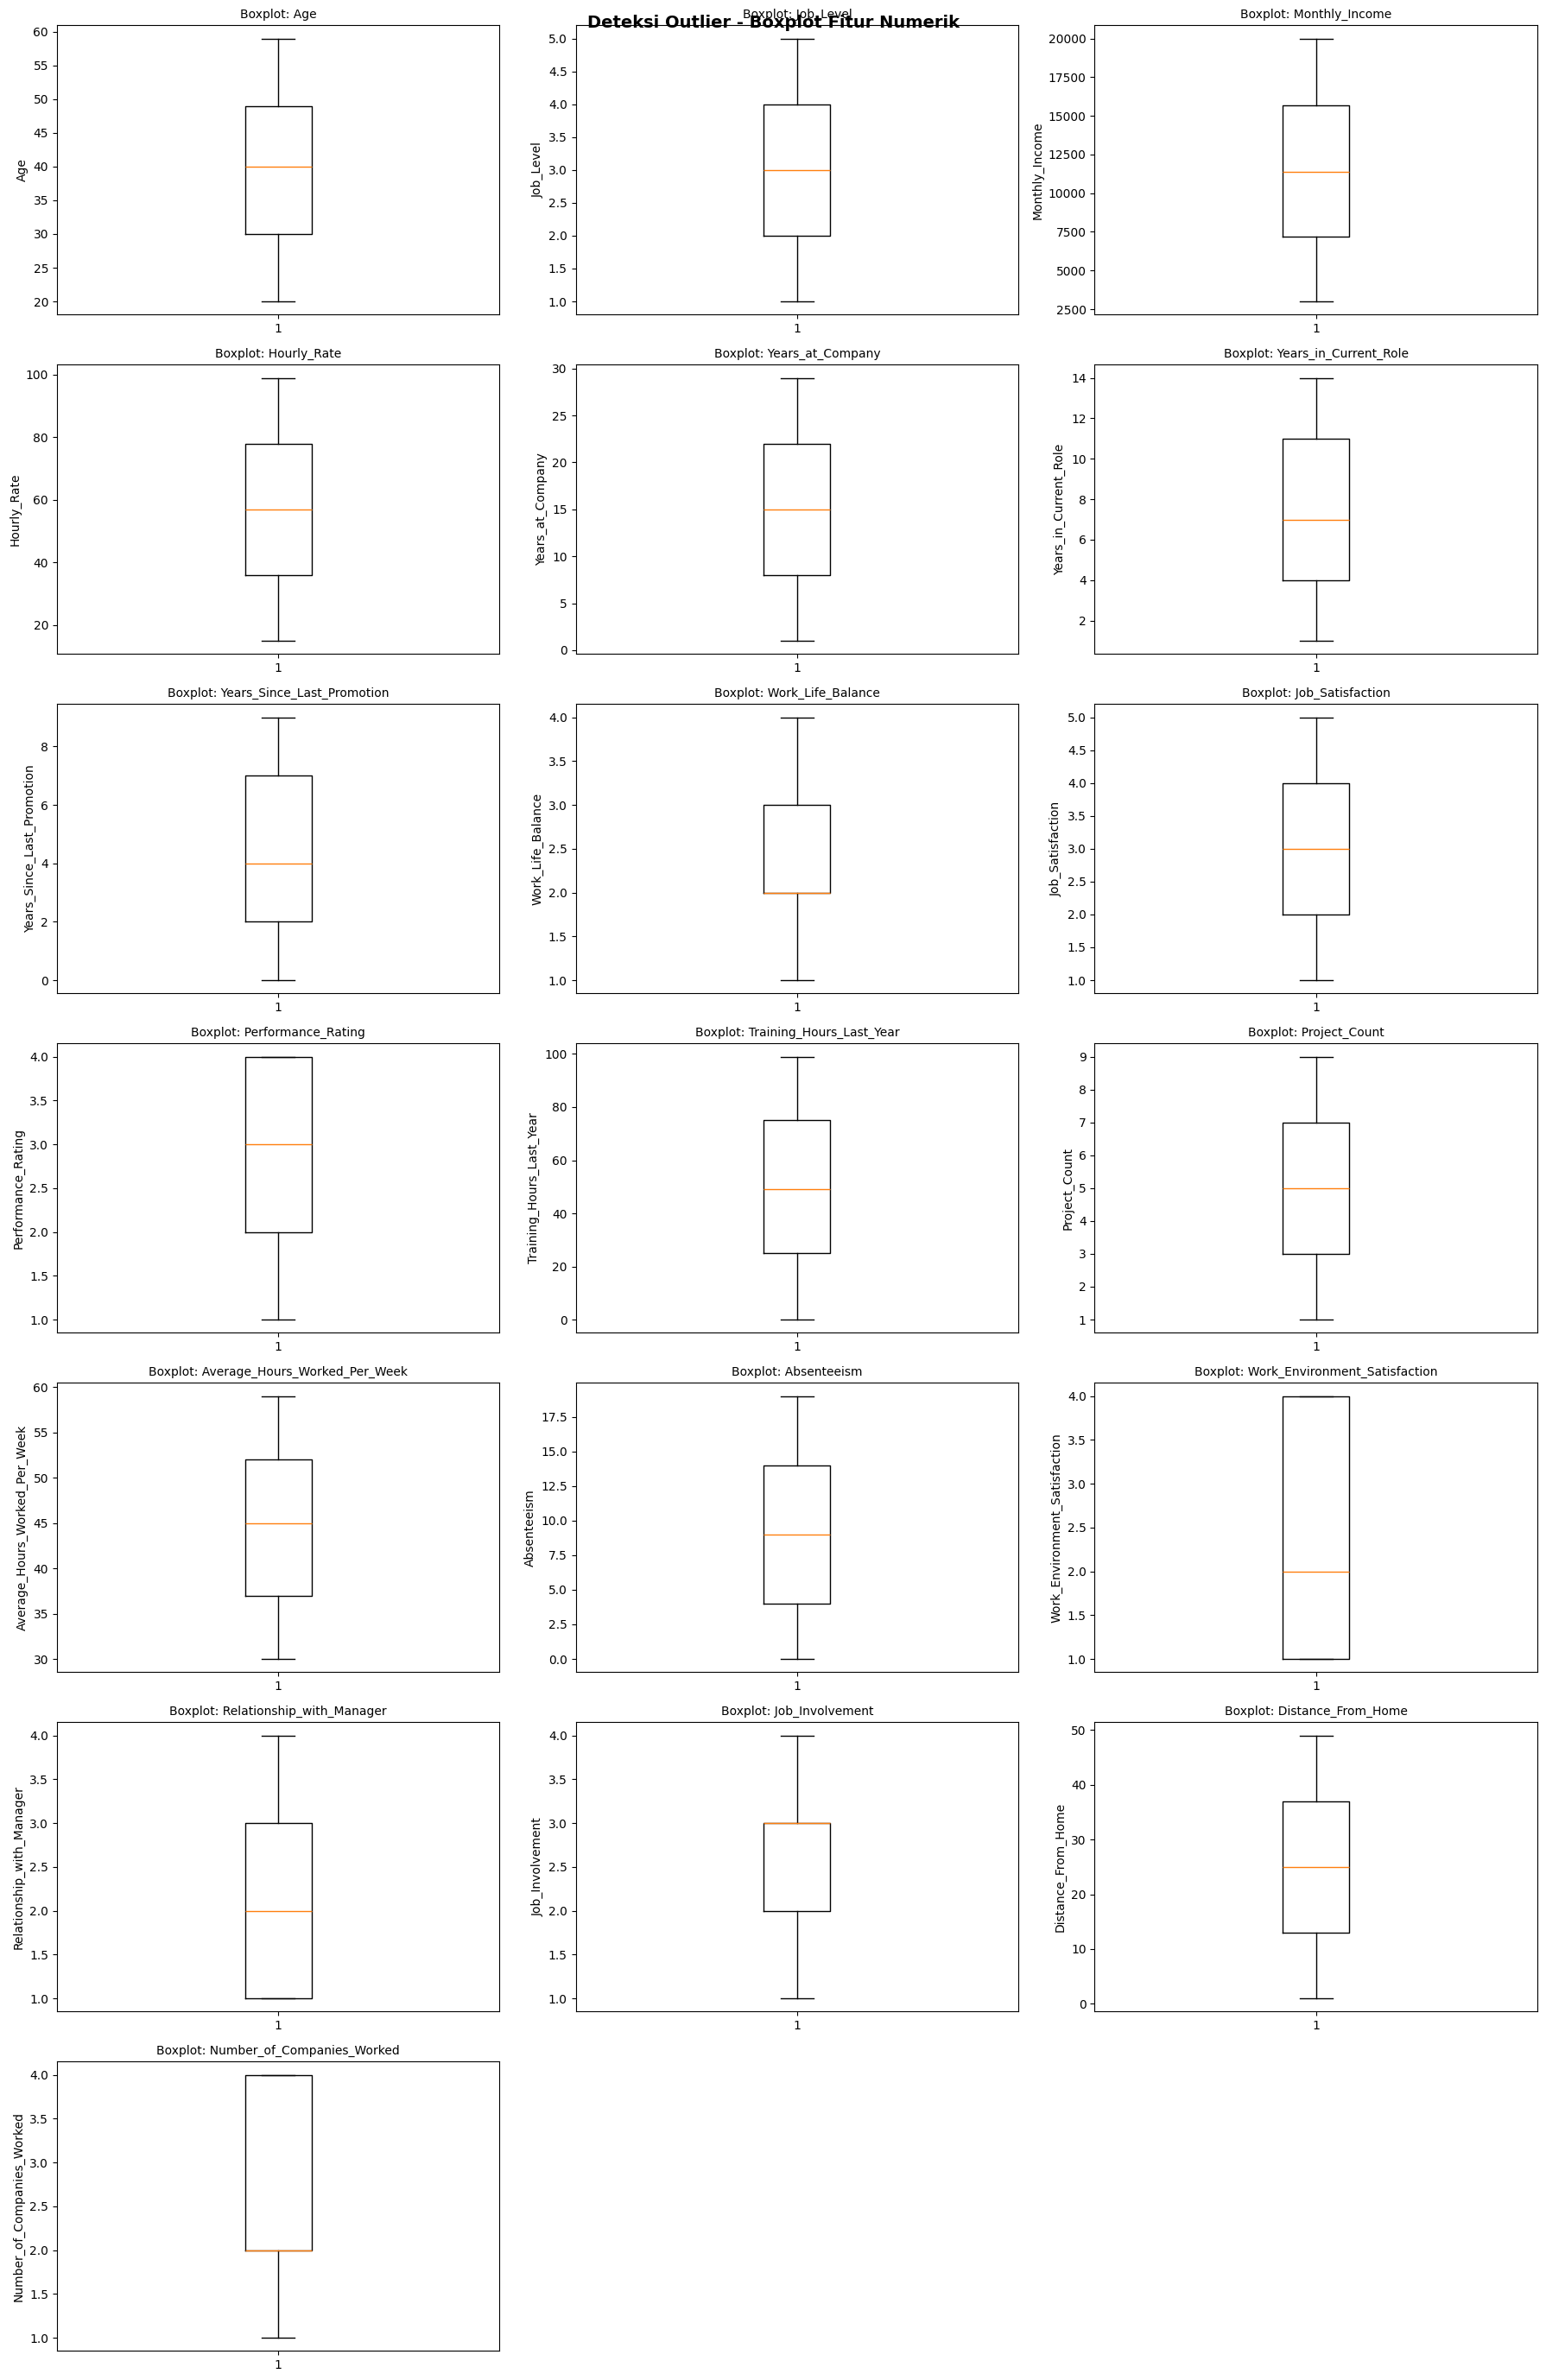

In [61]:
# Visualisasi outlier dengan boxplot
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Hapus target dari visualisasi outlier
target_col = 'Attrition'
num_features_plot = [col for col in num_features if col != target_col]

n_cols = 3
n_rows = (len(num_features_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features_plot):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot: {col}', fontsize=10)
    axes[i].set_ylabel(col)

# Sembunyikan axes kosong
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier - Boxplot Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
# Deteksi outlier dengan IQR dan tangani dengan capping (Winsorization)
def cap_outliers_iqr(df, col, lower_pct=0.01, upper_pct=0.99):
    """Cap outlier menggunakan percentile (lebih aman dari drop)."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    if n_outliers > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'  ⚠️  {col}: {n_outliers} outlier di-cap (lower={lower:.2f}, upper={upper:.2f})')
    
    return df

# Kolom yang perlu dicek outlier (skip rating 1-5 karena bounded)
bounded_cols = ['Job_Satisfaction', 'Performance_Rating', 'Work_Environment_Satisfaction',
                'Relationship_with_Manager', 'Job_Involvement', 'Job_Level']
outlier_cols = [col for col in num_features_plot if col not in bounded_cols]

print('=== PENANGANAN OUTLIER (IQR Capping) ===')
for col in outlier_cols:
    df = cap_outliers_iqr(df, col)

print('\n✅ Outlier selesai ditangani!')

=== PENANGANAN OUTLIER (IQR Capping) ===

✅ Outlier selesai ditangani!


### 3.5 Cek Konsistensi Data

In [63]:
# Cek nilai unik pada kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print('=== NILAI UNIK KOLOM KATEGORIKAL ===')
for col in cat_cols:
    print(f'\n📌 {col} ({df[col].nunique()} unik): {df[col].unique().tolist()}')

=== NILAI UNIK KOLOM KATEGORIKAL ===

📌 Gender (2 unik): ['Male', 'Female']

📌 Marital_Status (3 unik): ['Single', 'Divorced', 'Married']

📌 Department (5 unik): ['Finance', 'HR', 'Marketing', 'Sales', 'IT']

📌 Job_Role (4 unik): ['Manager', 'Assistant', 'Analyst', 'Executive']

📌 Overtime (2 unik): ['No', 'Yes']

📌 Attrition (2 unik): ['No', 'Yes']


In [64]:
# Standardisasi format teks (lowercase, strip whitespace)
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print('✅ Format teks kolom kategorikal sudah dirapikan.')

# Cek distribusi target
print('\n=== DISTRIBUSI TARGET (Attrition) ===')
if 'Attrition' in df.columns:
    print(df['Attrition'].value_counts())
    print(f'Proporsi: {df["Attrition"].value_counts(normalize=True).round(3).to_dict()}')

✅ Format teks kolom kategorikal sudah dirapikan.

=== DISTRIBUSI TARGET (Attrition) ===
Attrition
No     8003
Yes    1997
Name: count, dtype: int64
Proporsi: {'No': 0.8, 'Yes': 0.2}


---
## ⚙️ 4. DATA PREPROCESSING

### 4.1 Encoding Target Variable

In [65]:
# Encode target: Yes=1, No=0
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
    print('✅ Target Attrition di-encode: Yes=1, No=0')

print(f'Distribusi target setelah encoding:\n{df["Attrition"].value_counts()}')

✅ Target Attrition di-encode: Yes=1, No=0
Distribusi target setelah encoding:
Attrition
0    8003
1    1997
Name: count, dtype: int64


### 4.2 Encoding Fitur Kategorikal

In [66]:
# Identifikasi kolom kategorikal (kecuali target)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Attrition']

print(f'Kolom kategorikal yang akan di-encode: {cat_cols}')

# Binary encoding (kolom dengan 2 nilai unik)
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
# One-Hot encoding (kolom dengan >2 nilai unik)
onehot_cols = [col for col in cat_cols if df[col].nunique() > 2]

print(f'\nBinary encoding: {binary_cols}')
print(f'One-Hot encoding: {onehot_cols}')

Kolom kategorikal yang akan di-encode: ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']

Binary encoding: ['Gender', 'Overtime']
One-Hot encoding: ['Marital_Status', 'Department', 'Job_Role']


In [67]:
# Binary Encoding
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f'✅ Binary encode: {col} → {df[col].unique()}')

# One-Hot Encoding
if onehot_cols:
    df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
    print(f'\n✅ One-Hot encode selesai: {onehot_cols}')

print(f'\n📊 Shape setelah encoding: {df.shape}')
df.head()

✅ Binary encode: Gender → [1 0]
✅ Binary encode: Overtime → [0 1]

✅ One-Hot encode selesai: ['Marital_Status', 'Department', 'Job_Role']

📊 Shape setelah encoding: (10000, 31)


,Age,Gender,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Attrition,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager
0,58,1,5,7332,81,24,12,3,1,3,...,0,False,True,False,False,False,False,False,False,True
1,48,0,4,6069,55,18,7,5,1,2,...,0,False,False,True,False,False,False,True,False,False
2,34,0,4,11485,65,6,4,3,4,5,...,1,True,False,False,False,True,False,False,False,True
3,27,0,4,18707,28,12,9,1,1,1,...,0,False,False,True,False,False,False,False,False,True
4,40,1,1,16398,92,3,9,1,3,4,...,0,True,False,True,False,False,False,False,False,False


### 4.3 Pisah Fitur dan Target

In [68]:
# Pisah fitur (X) dan target (y)
X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f'✅ Shape X (fitur): {X.shape}')
print(f'✅ Shape y (target): {y.shape}')
print(f'\nDistribusi kelas target:')
print(y.value_counts())
print(f'  → Class 0 (No Attrition): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  → Class 1 (Attrition):    {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')

✅ Shape X (fitur): (10000, 30)
✅ Shape y (target): (10000,)

Distribusi kelas target:
Attrition
0    8003
1    1997
Name: count, dtype: int64
  → Class 0 (No Attrition): 8003 (80.0%)
  → Class 1 (Attrition):    1997 (20.0%)


### 4.4 Feature Scaling (Normalisasi)

In [69]:
# Identifikasi kolom numerik yang perlu di-scale
# (skip kolom boolean/dummy hasil encoding)
bool_cols = X.select_dtypes(include=['bool', 'uint8']).columns.tolist()
scale_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols = [col for col in scale_cols if col not in bool_cols]

# Gender & Overtime ke pengecualian ( sudah di-encode jadi 0 dan 1 )
binary_encoded = ['Gender', 'Overtime']
scale_cols = [col for col in scale_cols if col not in binary_encoded]

print(f'Kolom yang akan di-scale ({len(scale_cols)} kolom):')
print(scale_cols)

# StandardScaler (mean=0, std=1) — cocok untuk model berbasis jarak
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'\n✅ Scaling selesai dengan StandardScaler')
print(f'Contoh sebelum scaling (Monthly_Income):')
print(f'  Mean={X["Monthly_Income"].mean():.2f}, Std={X["Monthly_Income"].std():.2f}' if 'Monthly_Income' in X.columns else '')
print(f'Contoh setelah scaling:')
print(f'  Mean={X_scaled["Monthly_Income"].mean():.4f}, Std={X_scaled["Monthly_Income"].std():.4f}' if 'Monthly_Income' in X_scaled.columns else '')

Kolom yang akan di-scale (19 kolom):
['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']

✅ Scaling selesai dengan StandardScaler
Contoh sebelum scaling (Monthly_Income):
  Mean=11436.72, Std=4926.53
Contoh setelah scaling:
  Mean=-0.0000, Std=1.0001


---
## 🔧 5. FEATURE ENGINEERING

### 5.1 Buat Fitur Baru dari Kolom yang Ada

In [70]:
# Gunakan df sebelum scaling untuk feature engineering
df_fe = df.copy()

# ── FITUR 1: Salary-to-Experience Ratio
# Mengukur apakah karyawan dibayar sesuai pengalamannya
if 'Monthly_Income' in df_fe.columns and 'Years_at_Company' in df_fe.columns:
    df_fe['Salary_Experience_Ratio'] = df_fe['Monthly_Income'] / (df_fe['Years_at_Company'] + 1)
    print('✅ Salary_Experience_Ratio = Monthly_Income / (Years_at_Company + 1)')

# ── FITUR 2: Workload Score
# Gabungan jam kerja dan jumlah proyek — proxy burnout
if 'Average_Hours_Worked_Per_Week' in df_fe.columns and 'Project_Count' in df_fe.columns:
    df_fe['Workload_Score'] = df_fe['Average_Hours_Worked_Per_Week'] * df_fe['Project_Count']
    print('✅ Workload_Score = Average_Hours_Worked_Per_Week × Project_Count')

# ── FITUR 3: Job Satisfaction Index
# Rata-rata kepuasan keseluruhan karyawan
satisfaction_cols = ['Job_Satisfaction', 'Work_Environment_Satisfaction',
                     'Relationship_with_Manager', 'Job_Involvement']
available_sat = [col for col in satisfaction_cols if col in df_fe.columns]
if available_sat:
    df_fe['Overall_Satisfaction_Index'] = df_fe[available_sat].mean(axis=1)
    print(f'✅ Overall_Satisfaction_Index = mean({available_sat})')

# ── FITUR 4: Career Stagnation
# Lama di role yang sama vs total di perusahaan
if 'Years_in_Current_Role' in df_fe.columns and 'Years_at_Company' in df_fe.columns:
    df_fe['Career_Stagnation_Ratio'] = df_fe['Years_in_Current_Role'] / (df_fe['Years_at_Company'] + 1)
    print('✅ Career_Stagnation_Ratio = Years_in_Current_Role / (Years_at_Company + 1)')

# ── FITUR 5: High Workload Flag
# Flag biner: karyawan bekerja >45 jam/minggu
if 'Average_Hours_Worked_Per_Week' in df_fe.columns:
    df_fe['Is_Overworked'] = (df_fe['Average_Hours_Worked_Per_Week'] > 45).astype(int)
    print('✅ Is_Overworked = 1 jika Average_Hours_Worked_Per_Week > 45')

# ── FITUR 6: Absenteeism Risk
# Flag absensi tinggi (>5 hari)
if 'Absenteeism' in df_fe.columns:
    df_fe['High_Absenteeism'] = (df_fe['Absenteeism'] > 5).astype(int)
    print('✅ High_Absenteeism = 1 jika Absenteeism > 5 hari')

# ── FITUR 7: Age Group
# Binning usia menjadi kategori generasi
if 'Age' in df_fe.columns:
    bins = [0, 25, 35, 45, 100]
    labels = ['Gen_Z', 'Millennial', 'Gen_X', 'Boomer']
    df_fe['Age_Group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels, right=False)
    df_fe = pd.get_dummies(df_fe, columns=['Age_Group'], drop_first=True)
    print('✅ Age_Group = binning usia (Gen_Z / Millennial / Gen_X / Boomer)')

print(f'\n📊 Shape setelah feature engineering: {df_fe.shape}')

✅ Salary_Experience_Ratio = Monthly_Income / (Years_at_Company + 1)
✅ Workload_Score = Average_Hours_Worked_Per_Week × Project_Count
✅ Overall_Satisfaction_Index = mean(['Job_Satisfaction', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement'])
✅ Career_Stagnation_Ratio = Years_in_Current_Role / (Years_at_Company + 1)
✅ Is_Overworked = 1 jika Average_Hours_Worked_Per_Week > 45
✅ High_Absenteeism = 1 jika Absenteeism > 5 hari
✅ Age_Group = binning usia (Gen_Z / Millennial / Gen_X / Boomer)

📊 Shape setelah feature engineering: (10000, 40)


### 5.2 Ringkasan Fitur Baru

In [71]:
new_features = [
    'Salary_Experience_Ratio', 'Workload_Score', 'Overall_Satisfaction_Index',
    'Career_Stagnation_Ratio', 'Is_Overworked', 'High_Absenteeism'
]
existing_new = [f for f in new_features if f in df_fe.columns]

print('=== STATISTIK FITUR BARU ===')
print(df_fe[existing_new].describe().round(3))

=== STATISTIK FITUR BARU ===
       Salary_Experience_Ratio  Workload_Score  Overall_Satisfaction_Index  \
count                10000.000       10000.000                   10000.000   
mean                  1190.012         221.810                       2.632   
std                   1379.129         124.768                       0.595   
min                    101.500          30.000                       1.000   
25%                    433.982         114.000                       2.250   
50%                    716.925         216.000                       2.750   
75%                   1322.000         312.000                       3.000   
max                   9989.500         531.000                       4.250   

       Career_Stagnation_Ratio  Is_Overworked  High_Absenteeism  
count                10000.000      10000.000         10000.000  
mean                     0.778          0.467             0.694  
std                      0.967          0.499             0.461  
min 

### 5.3 Korelasi Fitur Baru dengan Target

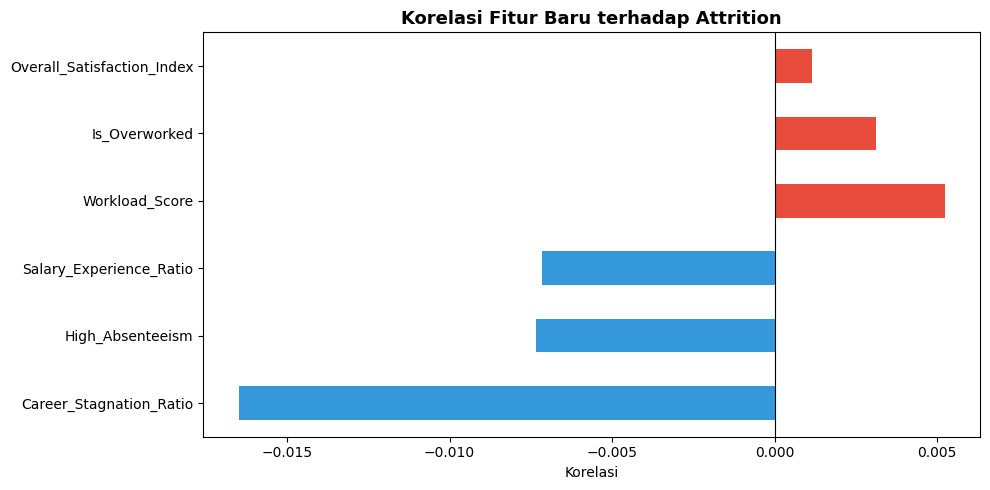

Nilai korelasi fitur baru:
Career_Stagnation_Ratio      -0.0165
High_Absenteeism             -0.0073
Salary_Experience_Ratio      -0.0071
Workload_Score                0.0052
Is_Overworked                 0.0031
Overall_Satisfaction_Index    0.0011
Name: Attrition, dtype: float64


In [72]:
# Korelasi fitur baru terhadap target Attrition
target_corr = df_fe[existing_new + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title('Korelasi Fitur Baru terhadap Attrition', fontsize=13, fontweight='bold')
plt.xlabel('Korelasi')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Nilai korelasi fitur baru:')
print(target_corr.round(4))

### 5.4 Re-scaling Setelah Feature Engineering

In [73]:
# Pisah ulang X dan y dari df_fe
X_final = df_fe.drop(columns=['Attrition'])
y_final = df_fe['Attrition']

# Scale ulang semua kolom numerik
bool_cols_fe = X_final.select_dtypes(include=['bool', 'uint8']).columns.tolist()
scale_cols_fe = X_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
scale_cols_fe = [col for col in scale_cols_fe if col not in bool_cols_fe]

scaler_final = StandardScaler()
X_final_scaled = X_final.copy()
X_final_scaled[scale_cols_fe] = scaler_final.fit_transform(X_final[scale_cols_fe])

print(f'✅ Final X shape (siap untuk modeling): {X_final_scaled.shape}')
print(f'✅ Final y shape: {y_final.shape}')
X_final_scaled.head()

✅ Final X shape (siap untuk modeling): (10000, 39)
✅ Final y shape: (10000,)


,Age,Gender,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Job_Role_Manager,Salary_Experience_Ratio,Workload_Score,Overall_Satisfaction_Index,Career_Stagnation_Ratio,Is_Overworked,High_Absenteeism,Age_Group_Millennial,Age_Group_Gen_X,Age_Group_Boomer
0,1.609703,1.008436,1.424386,-0.833228,0.970273,1.075026,1.125164,-0.509049,-1.350724,-0.026861,...,True,-0.650248,1.684730,-0.642087,-0.308453,1.069188,0.664332,False,False,True
1,0.736677,-0.991635,0.715454,-1.089608,-0.082273,0.363387,-0.111633,0.182641,-1.350724,-0.733728,...,False,-0.631293,2.333968,-1.062328,-0.423841,1.069188,0.664332,False,False,True
2,-0.485560,-0.991635,0.715454,0.009801,0.322552,-1.059892,-0.853711,-0.509049,1.346409,1.386873,...,True,0.326818,-0.455353,1.038879,-0.213904,1.069188,-1.505271,True,False,False
3,-1.096678,-0.991635,0.715454,1.475816,-1.175300,-0.348253,0.383086,-1.200738,-1.350724,-1.440595,...,True,0.180549,2.045418,-0.642087,-0.088899,1.069188,-1.505271,True,False,False
4,0.038256,1.008436,-1.411342,1.007105,1.415580,-1.415712,0.383086,-1.200738,0.447364,0.680006,...,False,2.109761,-1.345050,-1.482570,1.521961,1.069188,0.664332,False,True,False


---
## 💾 6. Simpan Hasil Data Preparation

In [74]:
# Simpan dataset bersih + hasil feature engineering
df_fe.to_csv('../data/employee_attrition_clean.csv', index=False)
X_final_scaled.to_csv('../data/X_preprocessed.csv', index=False)
y_final.to_csv('../data/y_target.csv', index=False)

print('✅ File tersimpan:')
print('  - employee_attrition_clean.csv  → dataset lengkap setelah cleaning + FE')
print('  - X_preprocessed.csv           → fitur siap modeling (sudah scaled)')
print('  - y_target.csv                 → label target')

✅ File tersimpan:
  - employee_attrition_clean.csv  → dataset lengkap setelah cleaning + FE
  - X_preprocessed.csv           → fitur siap modeling (sudah scaled)
  - y_target.csv                 → label target


---
## 📋 7. Ringkasan Data Preparation

In [78]:
print('=' * 55)
print('RINGKASAN DATA PREPARATION '.center(55))
print('=' * 55)

print(f'\n📌 DATASET AWAL')
print(f'   Shape         : {df_original.shape}')

print(f'\n🧹 DATA CLEANING')
print(f'   Missing values: Ditangani (median/modus)')
print(f'   Duplikat      : Dihapus')
print(f'   Kolom ID      : Dihapus (Employee_ID)')
print(f'   Outlier       : Di-cap dengan IQR method')

print(f'\n⚙️  DATA PREPROCESSING')
print(f'   Target encode : Yes=1, No=0')
print(f'   Cat. encode   : Binary (Label) + One-Hot')
print(f'   Scaling       : StandardScaler')

print(f'\n🔧 FEATURE ENGINEERING (7 fitur baru)')
print(f'   1. Salary_Experience_Ratio')
print(f'   2. Workload_Score')
print(f'   3. Overall_Satisfaction_Index')
print(f'   4. Career_Stagnation_Ratio')
print(f'   5. Is_Overworked (flag)')
print(f'   6. High_Absenteeism (flag)')
print(f'   7. Age_Group (binning → dummy)')

print(f'\n📊 DATASET FINAL')
print(f'   Shape X       : {X_final_scaled.shape}')
print(f'   Shape y       : {y_final.shape}')
print(f'   Attrition=1   : {y_final.sum()} ({y_final.mean()*100:.1f}%)')
print(f'   Attrition=0   : {(y_final==0).sum()} ({(y_final==0).mean()*100:.1f}%)')
print('=' * 55)

              RINGKASAN DATA PREPARATION               

📌 DATASET AWAL
   Shape         : (10000, 26)

🧹 DATA CLEANING
   Missing values: Ditangani (median/modus)
   Duplikat      : Dihapus
   Kolom ID      : Dihapus (Employee_ID)
   Outlier       : Di-cap dengan IQR method

⚙️  DATA PREPROCESSING
   Target encode : Yes=1, No=0
   Cat. encode   : Binary (Label) + One-Hot
   Scaling       : StandardScaler

🔧 FEATURE ENGINEERING (7 fitur baru)
   1. Salary_Experience_Ratio
   2. Workload_Score
   3. Overall_Satisfaction_Index
   4. Career_Stagnation_Ratio
   5. Is_Overworked (flag)
   6. High_Absenteeism (flag)
   7. Age_Group (binning → dummy)

📊 DATASET FINAL
   Shape X       : (10000, 39)
   Shape y       : (10000,)
   Attrition=1   : 1997 (20.0%)
   Attrition=0   : 8003 (80.0%)
